In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuração visual profissional
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# Recarrega a base
df = pd.read_csv('../02_dados_tratados/base_consolidada.csv', sep=';', encoding='utf-8-sig')

# Filtra só o trimestre mais recente para comparativos estáticos
df_atual = df[df['Trimestre'] == '2025T4'].copy()

print(f"✅ Pronto para análise visual!")
print(f"   Base completa: {len(df)} linhas")
print(f"   Snapshot T4 2025: {len(df_atual)} bancos")


✅ Pronto para análise visual!
   Base completa: 78 linhas
   Snapshot T4 2025: 11 bancos


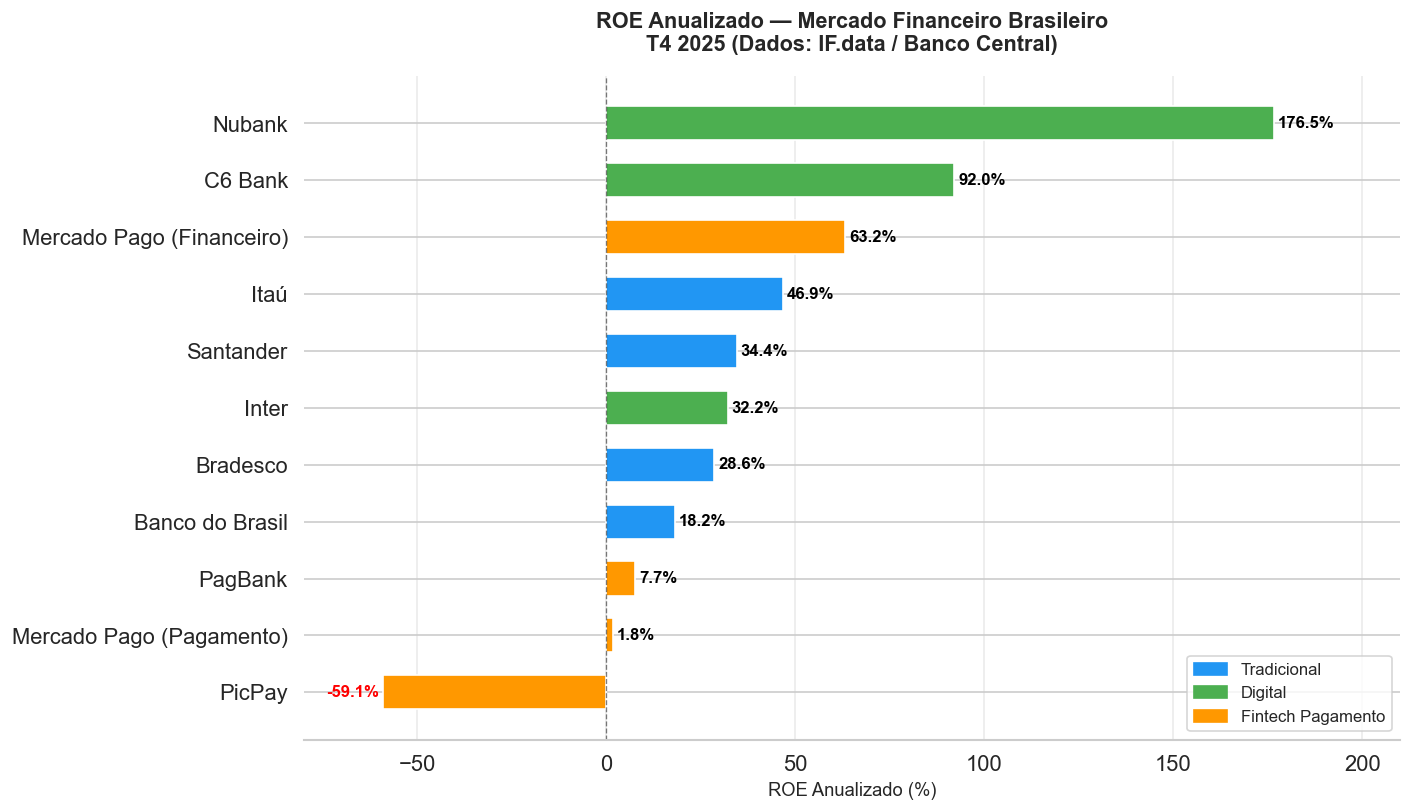

✅ Gráfico salvo em 06_relatorio_executivo/


In [2]:
# Gráfico 1 — Ranking de ROE T4 2025
fig, ax = plt.subplots(figsize=(12, 7))

# Ordena do maior para o menor ROE
df_roe = df_atual[['Banco', 'Categoria', 'ROE_anualizado']].copy()
df_roe = df_roe.sort_values('ROE_anualizado', ascending=True)

# Cores por categoria
cores = {
    'Tradicional': '#2196F3',
    'Digital': '#4CAF50',
    'Fintech Pagamento': '#FF9800'
}
cores_barras = df_roe['Categoria'].map(cores)

# Cria as barras horizontais
bars = ax.barh(df_roe['Banco'], df_roe['ROE_anualizado'] * 100,
               color=cores_barras, edgecolor='white', height=0.6)

# Adiciona os valores nas barras
for bar, val in zip(bars, df_roe['ROE_anualizado'] * 100):
    x = bar.get_width()
    label_x = x + 1 if x >= 0 else x - 1
    ha = 'left' if x >= 0 else 'right'
    color = 'black' if x >= 0 else 'red'
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{x:.1f}%', va='center', ha=ha, fontsize=10, color=color, fontweight='bold')

# Linha de zero (referência)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Legenda de categorias
from matplotlib.patches import Patch
legenda = [Patch(color=c, label=cat) for cat, c in cores.items()]
ax.legend(handles=legenda, loc='lower right', fontsize=10)

# Títulos e formatação
ax.set_title('ROE Anualizado — Mercado Financeiro Brasileiro\nT4 2025 (Dados: IF.data / Banco Central)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('ROE Anualizado (%)', fontsize=11)
ax.set_xlim(-80, 210)
ax.grid(axis='x', alpha=0.4)
sns.despine(left=True)

plt.tight_layout()
plt.savefig('../06_relatorio_executivo/grafico_roe_t4_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em 06_relatorio_executivo/")

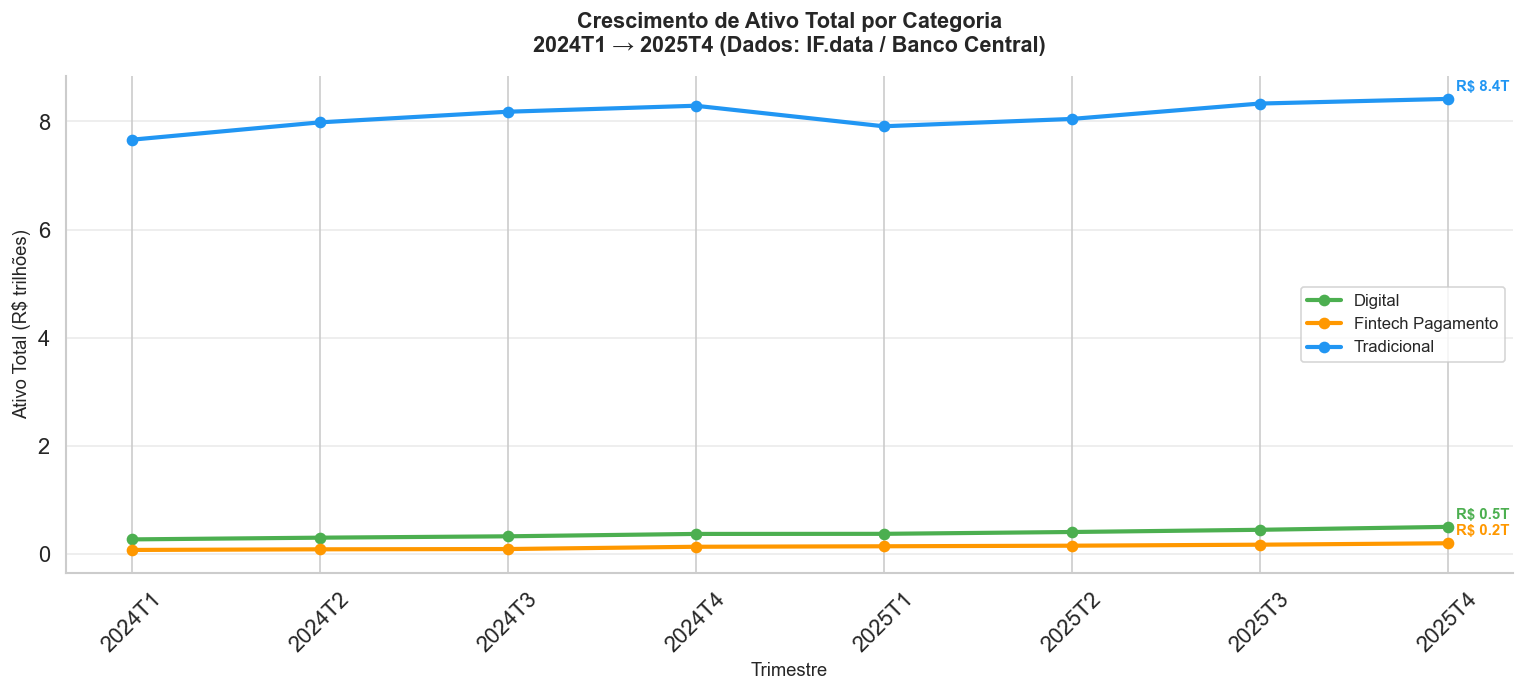

✅ Gráfico 2 salvo!


In [3]:
# Gráfico 2 — Crescimento de Ativo Total por categoria ao longo do tempo
# Agrupa por categoria e trimestre, soma os ativos
df_cat = df.groupby(['Categoria', 'Trimestre'])['Ativo Total'].sum().reset_index()

# Ordena os trimestres cronologicamente
ordem_trimestres = sorted(df['Trimestre'].unique())
df_cat['Trimestre'] = pd.Categorical(df_cat['Trimestre'], categories=ordem_trimestres, ordered=True)
df_cat = df_cat.sort_values(['Categoria', 'Trimestre'])

# Converte para trilhões (fica mais legível)
df_cat['Ativo Total (R$ tri)'] = df_cat['Ativo Total'] / 1_000_000_000

# Cores por categoria
cores_linha = {
    'Tradicional': '#2196F3',
    'Digital': '#4CAF50',
    'Fintech Pagamento': '#FF9800'
}

fig, ax = plt.subplots(figsize=(13, 6))

for categoria, grupo in df_cat.groupby('Categoria'):
    ax.plot(grupo['Trimestre'], grupo['Ativo Total (R$ tri)'],
            marker='o', linewidth=2.5, markersize=6,
            label=categoria, color=cores_linha[categoria])
    # Adiciona valor no último ponto
    ultimo = grupo.iloc[-1]
    ax.annotate(f"R$ {ultimo['Ativo Total (R$ tri)']:.1f}T",
                xy=(ultimo['Trimestre'], ultimo['Ativo Total (R$ tri)']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color=cores_linha[categoria], fontweight='bold')

ax.set_title('Crescimento de Ativo Total por Categoria\n2024T1 → 2025T4 (Dados: IF.data / Banco Central)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trimestre', fontsize=11)
ax.set_ylabel('Ativo Total (R$ trilhões)', fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.savefig('../06_relatorio_executivo/grafico_ativo_total.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 salvo!")

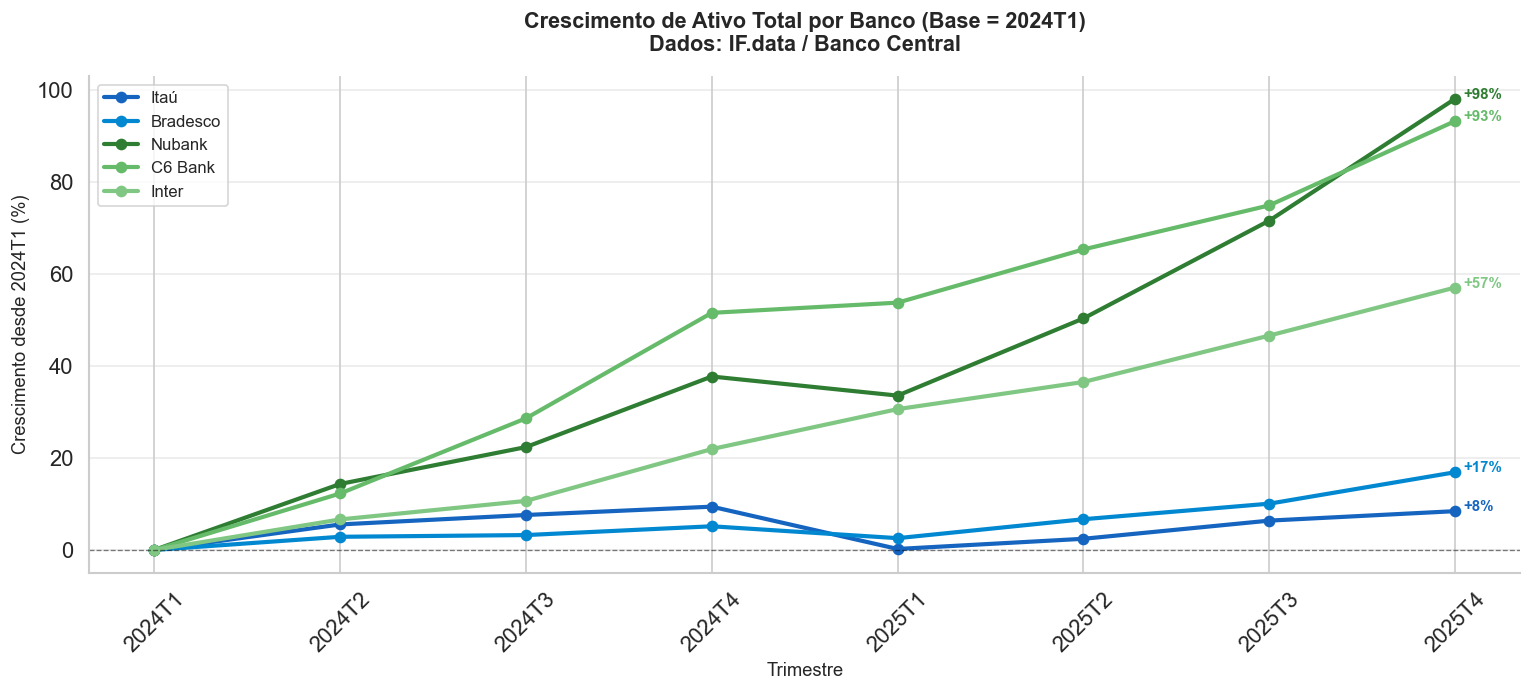

Grafico 3 salvo!


In [5]:
# Gráfico 3 — Crescimento percentual de Ativo Total por banco
bancos_principais = ['Itaú', 'Bradesco', 'Nubank', 'C6 Bank', 'Inter']

fig, ax = plt.subplots(figsize=(13, 6))

cores_banco = {
    'Itaú': '#1565C0',
    'Bradesco': '#0288D1',
    'Nubank': '#2E7D32',
    'C6 Bank': '#66BB6A',
    'Inter': '#81C784'
}

for banco in bancos_principais:
    dados = df[df['Banco'] == banco].sort_values('Trimestre').copy()
    base = dados['Ativo Total'].iloc[0]
    dados['crescimento_pct'] = ((dados['Ativo Total'] - base) / base) * 100

    ax.plot(dados['Trimestre'], dados['crescimento_pct'],
            marker='o', linewidth=2.5, markersize=6,
            label=banco, color=cores_banco[banco])

    ultimo = dados.iloc[-1]
    ax.annotate(f"+{ultimo['crescimento_pct']:.0f}%",
                xy=(ultimo['Trimestre'], ultimo['crescimento_pct']),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, color=cores_banco[banco], fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Crescimento de Ativo Total por Banco (Base = 2024T1)\nDados: IF.data / Banco Central',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trimestre', fontsize=11)
ax.set_ylabel('Crescimento desde 2024T1 (%)', fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.savefig('../06_relatorio_executivo/grafico_crescimento_pct.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico 3 salvo!")